In [2]:
!pip install pandas numpy scikit-learn missingno openpyxl

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#Load Data
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
import missingno as msno
import warnings
warnings.filterwarnings('ignore')


file_path = "BD_MedWaste_2000_2023.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist()[:10], "...")

Shape: (192, 44)
Columns: ['Year', 'Division', 'Number_of_Hospitals', 'Number_of_Beds', 'Crude_Birth_Rate', 'GDP_per_Capita_USD', 'Dengue_Cases', 'Beds_per_1000_Pop', 'Hospitals_per_100k_Pop', 'Avg_Beds_per_Hospital'] ...


,Missing_Count,Missing_%
Year,0,0.0
Division,0,0.0
Number_of_Hospitals,0,0.0
Number_of_Beds,0,0.0
Crude_Birth_Rate,0,0.0
GDP_per_Capita_USD,0,0.0
Dengue_Cases,0,0.0
Beds_per_1000_Pop,0,0.0
Hospitals_per_100k_Pop,0,0.0
Avg_Beds_per_Hospital,0,0.0


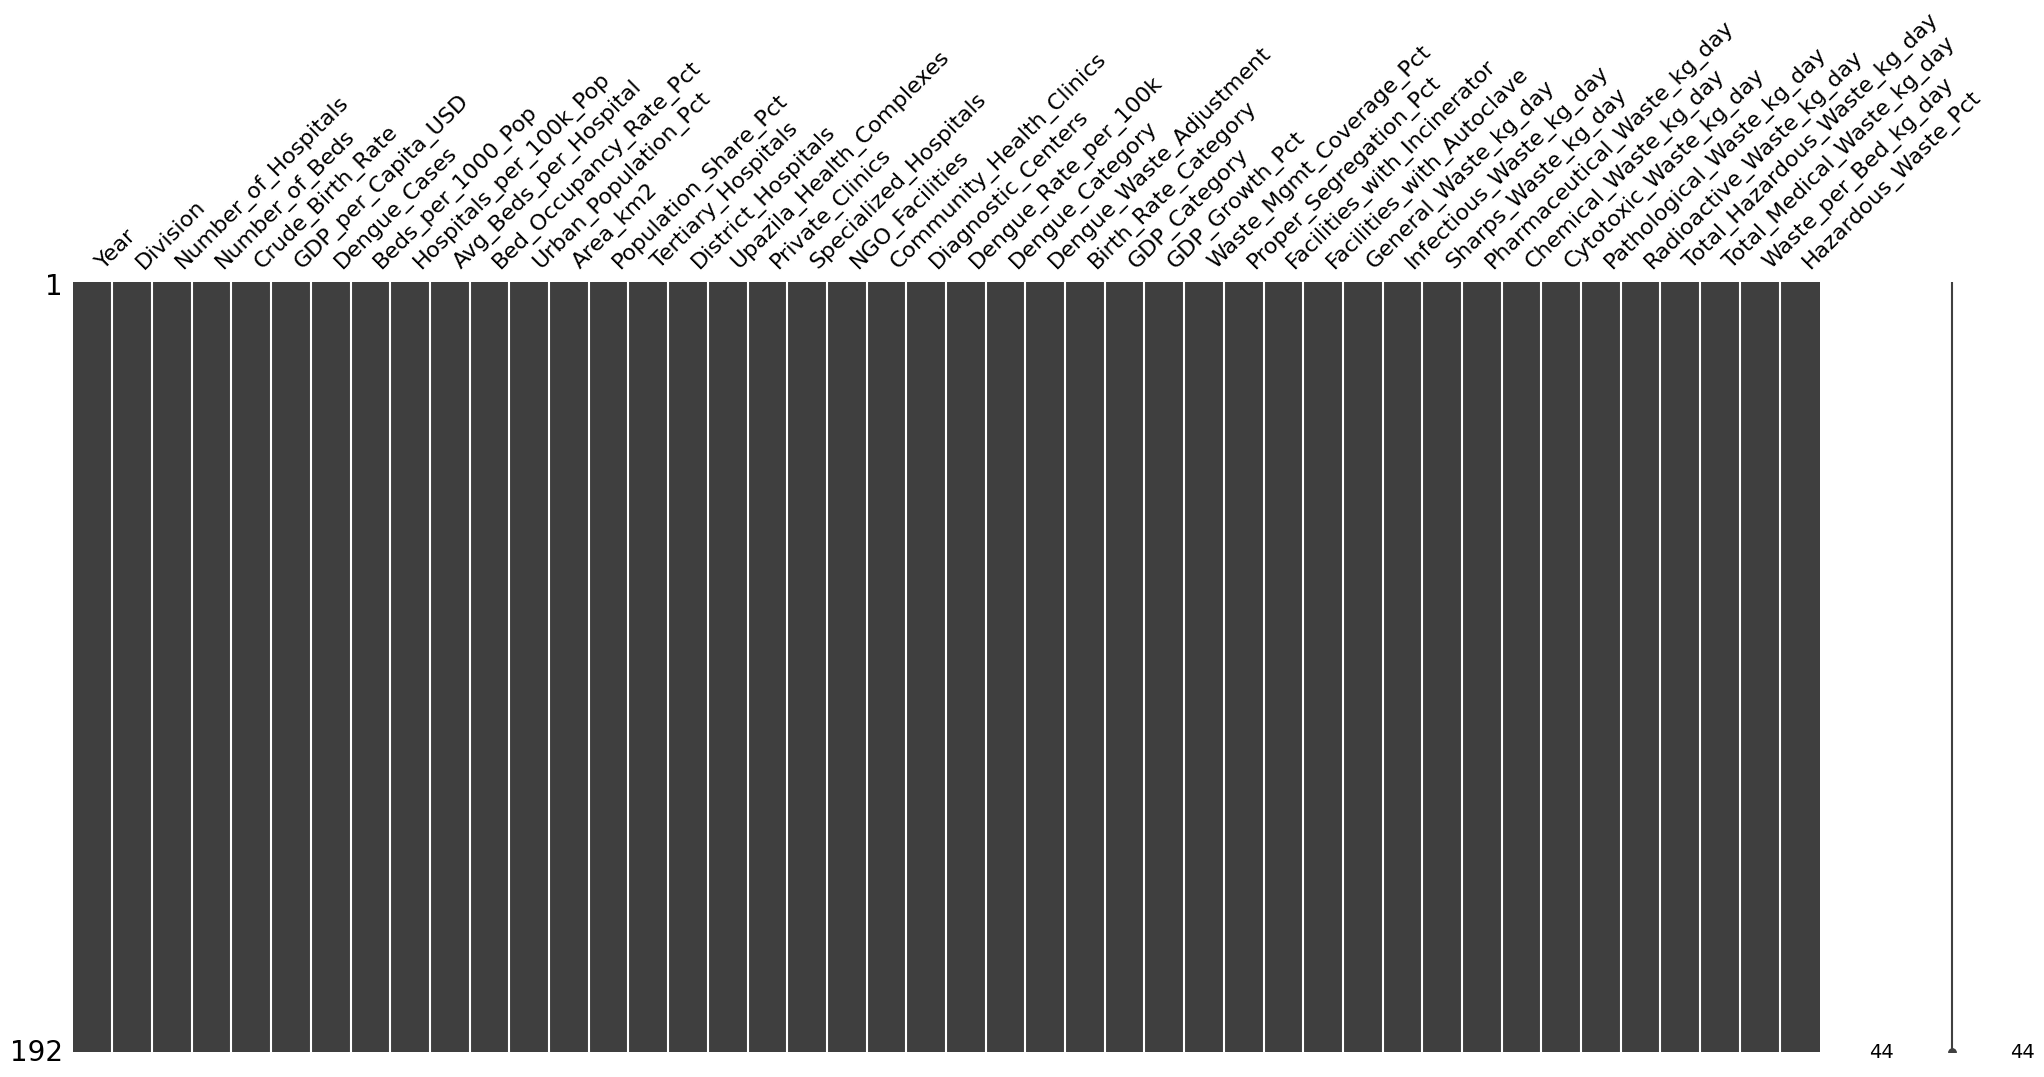

In [ ]:
# Audit missing values
# Missing counts and percentage
missing_summary = df.isna().sum().to_frame('Missing_Count')
missing_summary['Missing_%'] = 100 * missing_summary['Missing_Count'] / len(df)
display(missing_summary.sort_values('Missing_%', ascending=False))
# Visual missingness map (for visual inspection)
msno.matrix(df)
# Identify zero-coded missing values in epidemiological columns (such as no dengue reporting years)
zero_mask_cols = ['Dengue_Cases', 'Infectious_Waste_kg_day']
for col in zero_mask_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f" {col}: {zero_count} rows with zero — check if true zero or missing data.")

In [6]:
#Separate variable groups
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Time-series numeric columns that should respect temporal order
time_series_cols = [
    'GDP_per_Capita_USD', 'Crude_Birth_Rate', 'Number_of_Hospitals',
    'Number_of_Beds', 'Dengue_Cases'
]

In [18]:
# ----------------------------
# Step 0: Sort data properly
# ----------------------------
df = df.sort_values(['Division', 'Year'])

# ----------------------------
# Step 1: Time-series fill (FIXED: use transform, not apply)
# ----------------------------
df[time_series_cols] = df.groupby('Division')[time_series_cols].transform(
    lambda x: x.ffill().bfill()
)

# ----------------------------
# Step 2: KNN Imputation (FIXED: preserve DataFrame structure)
# ----------------------------
knn_numeric_cols = [col for col in numeric_cols if col not in ['Year']]

knn_imputer = KNNImputer(n_neighbors=5)

df[knn_numeric_cols] = pd.DataFrame(
    knn_imputer.fit_transform(df[knn_numeric_cols]),
    columns=knn_numeric_cols,
    index=df.index
)

# ----------------------------
# Step 3: Iterative Imputer (MICE) FIXED
# ----------------------------
iter_impute_cols = [
    'General_Waste_kg_day', 'Infectious_Waste_kg_day', 'Sharps_Waste_kg_day',
    'Pharmaceutical_Waste_kg_day', 'Chemical_Waste_kg_day',
    'Total_Medical_Waste_kg_day', 'Total_Hazardous_Waste_kg_day'
]

mice = IterativeImputer(random_state=42)

df[iter_impute_cols] = pd.DataFrame(
    mice.fit_transform(df[iter_impute_cols]),
    columns=iter_impute_cols,
    index=df.index
)

In [8]:
#Encode and impute categorical nulls
categorical_cols_with_nan = [col for col in categorical_cols if df[col].isna().any()]
for col in categorical_cols_with_nan:
    df[col] = df[col].fillna('Unknown')
# Encode categorical features (for model-ready ML version)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoded_df = df.copy()
encoded_df[categorical_cols] = encoder.fit_transform(encoded_df[categorical_cols])
print("Categorical encoding complete.")

Categorical encoding complete.


Remaining missing after imputation:
0
 Saved: cleaned and encoded files ready for modeling.


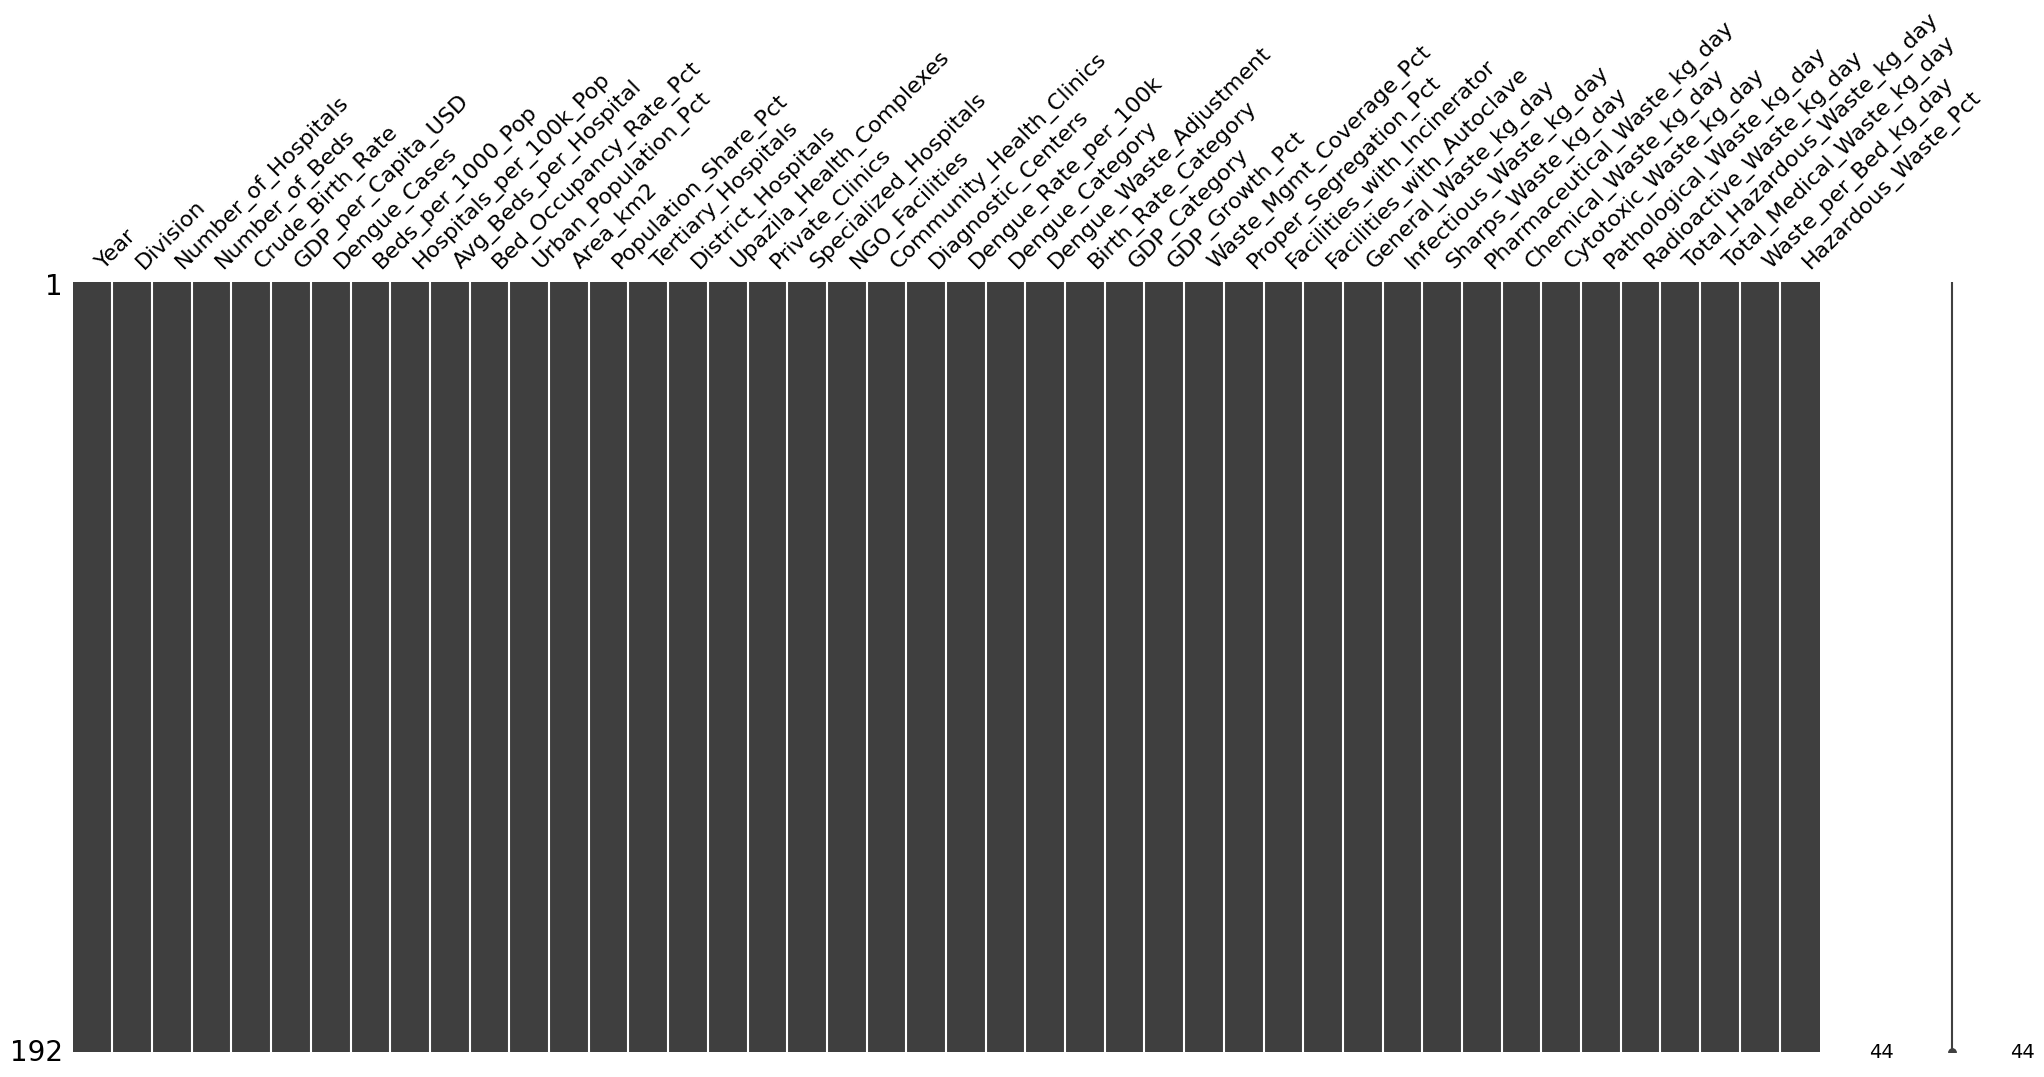

In [9]:
#Final check
print("Remaining missing after imputation:")
print(encoded_df.isna().sum().sum())
msno.matrix(encoded_df)
#Export cleaned datasets
encoded_df.to_csv("BD_MedWaste_2000_2023_Cleaned_Encoded.csv", index=False)
df.to_csv("BD_MedWaste_2000_2023_Cleaned.csv", index=False)
print(" Saved: cleaned and encoded files ready for modeling.")

In [27]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler

# 1. Load data
df = pd.read_csv("BD_MedWaste_2000_2023.csv")

# 2. Sort for time-series structure
df = df.sort_values(["Division", "Year"]).reset_index(drop=True)

raw_df = df.copy()


# 3. Target transformation
# Only apply if column exists
if "Total_Medical_Waste_kg_day" in df.columns:
    df["Waste_log"] = np.log1p(df["Total_Medical_Waste_kg_day"])


# 4. Time-series fill (AUTO SAFE)

ts_cols = df.select_dtypes(include=np.number).columns.tolist()
ts_cols = [c for c in ts_cols if c not in ["Year"]]

df[ts_cols] = df.groupby("Division")[ts_cols].transform(
    lambda x: x.ffill().bfill()
)
# 5. Lag features (ONLY if columns exist)

if "Dengue_Cases" in df.columns:
    df["Dengue_Cases_lag1"] = df.groupby("Division")["Dengue_Cases"].shift(1)

if "Total_Medical_Waste_kg_day" in df.columns:
    df["Waste_lag1"] = df.groupby("Division")["Total_Medical_Waste_kg_day"].shift(1)


# 6. Rolling features (SAFE)

if "Dengue_Cases" in df.columns:
    df["Dengue_roll3"] = df.groupby("Division")["Dengue_Cases"].transform(
        lambda x: x.rolling(3).mean()
    )

if "Total_Medical_Waste_kg_day" in df.columns:
    df["Waste_roll3"] = df.groupby("Division")["Total_Medical_Waste_kg_day"].transform(
        lambda x: x.rolling(3).mean()
    )


# 7. Interaction features (SAFE)

if "Hospitals" in df.columns:
    df["Waste_per_Hospital"] = df["Total_Medical_Waste_kg_day"] / (df["Hospitals"] + 1)
    df["Dengue_per_Hospital"] = df["Dengue_Cases"] / (df["Hospitals"] + 1)


# 8. Drop NaNs after feature engineering

df = df.dropna().reset_index(drop=True)


# 9. Time-based split (NO LEAKAGE)

train = df[df["Year"] <= 2017]
val   = df[(df["Year"] >= 2018) & (df["Year"] <= 2020)]
test  = df[df["Year"] >= 2021]


# 10. Feature selection (AUTO SAFE)

features = [c for c in [
    "Dengue_Cases",
    "Dengue_Cases_lag1",
    "Waste_lag1",
    "Dengue_roll3",
    "Waste_roll3",
    "Waste_per_Hospital",
    "Dengue_per_Hospital"
] if c in df.columns]

target = "Waste_log" if "Waste_log" in df.columns else "Total_Medical_Waste_kg_day"


# 11. Split X and y

X_train, y_train = train[features], train[target]
X_val, y_val     = val[features], val[target]
X_test, y_test   = test[features], test[target]


# 12. Scaling (ONLY for linear / NN models)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=features, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

# 13. Final output check

print("✅ Preprocessing completed successfully")
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

✅ Preprocessing completed successfully
Train shape: (128, 5)
Validation shape: (24, 5)
Test shape: (24, 5)
